In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer
)

In [32]:
pd.set_option("display.max_columns", 100)
df=pd.read_csv('house_sale.csv')

In [33]:
df.head()

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,92000.0,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,vipped,featured,NaN,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,NaN,95000.0,AZN,Elçin,mülkiyyətçi,NaN,NaN,Qaraçuxur qəs.,40.393614,49.981553,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,NaN,Obyekt,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,NaN,NaN,Agentlik,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,d71cf9a9-86dd-4162-b540-6252a8659a09,22d840df-9283-4112-bc71-7432511fc776,/items/4638863,2024-10-05 22:14:10.089116+00,Əhmədli qəs. Qaçaq Nəbi küçəsi 3 otaga duzelm...

`CheckPoint 1`

In [34]:
#Biznes problemi : Bazarda mənzilin satış qiymətinin düzgün müəyyən edilməsi həm satıcılar, həm alıcılar, həm də əmlak platformaları üçün vacibdir. Qiymətin subyektiv təyin olunması mənzilin bazar qiymətindən baha və ya ucuz təklif edilməsinə səbəb ola bilər. Bu layihənin məqsədi Bina.az elanlarından əldə edilmiş məlumatlardan istifadə edərək mənzilin xüsusiyyətlərinə əsasən onun təxmini satış qiymətini proqnozlaşdıran machine learning modeli qurmaqdır.

#Target dəyişən : Bu layihədə təxmin edəcəyimiz dəyişən mənzilin qiyməti (price) sütunudur. Digər sütunlar model üçün giriş dəyişənləri (features) kimi istifadə olunacaq.

#Problem növü : Target dəyişən ədədi və davamlı qiymət olduğuna görə bu məsələ supervised machine learning regression problemidir.

#Uğur metrikası : Modelin performansını qiymətləndirmək üçün əsas metrik kimi Root Mean Squared Error (RMSE) istifadə olunacaq. RMSE modelin proqnozlaşdırdığı qiymətlə real satış qiyməti arasındakı səhvin orta ölçüsünü göstərir və böyük səhvləri daha çox cəzalandırır. Əlavə olaraq Mean Absolute Error (MAE) və R² score da modelin nəticələrini daha geniş qiymətləndirmək üçün istifadə olunacaq.

#Layihənin məqsədi : Layihənin sonunda müxtəlif regression alqoritmləri eyni cross-validation metodologiyası və eyni metriklər əsasında müqayisə ediləcək, ən yaxşı model hyperparameter tuning ilə optimallaşdırılacaq və yalnız sonda ayrılmış test setində yekun performansı ölçüləcək.

#Uğur hədəfi : Modelin uğurlu sayılması üçün test setində RMSE-nin orta mənzil qiymətinin (~orta price) 25%-dən aşağı, R²-nin isə minimum 0.4-0.5 səviyyəsində olması hədəflənir. Bu hədəflər ilkin referans nöqtəsi kimi qəbul edilir və layihə gedişində lazım gəldikdə yenidən nəzərdən keçirilə bilər.

`CheckPoint 2`

In [35]:
df.head()

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,92000.0,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,vipped,featured,NaN,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,NaN,95000.0,AZN,Elçin,mülkiyyətçi,NaN,NaN,Qaraçuxur qəs.,40.393614,49.981553,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,NaN,Obyekt,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,NaN,NaN,Agentlik,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,d71cf9a9-86dd-4162-b540-6252a8659a09,22d840df-9283-4112-bc71-7432511fc776,/items/4638863,2024-10-05 22:14:10.089116+00,Əhmədli qəs. Qaçaq Nəbi küçəsi 3 otaga duzelm...

In [36]:
df.shape

(100775, 51)

In [37]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0].sort_values(
    "Missing %",
    ascending=False
)

missing

,Missing Count,Missing %
Binanın növü,100621,99.85
featured,97626,96.88
vip,92179,91.47
Torpaq sahəsi,85204,84.55
hour_y,85144,84.49
İpoteka,67836,67.31
mortgage,67836,67.31
shop_name,28757,28.54
shop_title,28757,28.54
products_label,28145,27.93


In [38]:
print("Missing price values:", df["price"].isnull().sum())

Missing price values: 0


In [39]:
#Datasetdə bəzi sütunlarda yüksək sayda missing value müşahidə etdim. Missing dəyərlər sütunların mənasına əsasən qiymətləndiriləcək və bütün sətirlər avtomatik olaraq silinməyəcək.

In [40]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [41]:
#Datasetdə duplicate sətir aşkar edilmədi, buna görə duplicate məlumatların silinməsinə ehtiyac olmadı.

In [42]:
drop_cols = [
    "id_x", "rel_url", "estate_rel_url_x", "img_url",
    "id_y", "estate_id", "estate_rel_url_y",
    "estate_details_id_x", "estate_details_id_y", "estate_rel_url",
    "hour_y", "hour_x"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")

In [43]:
# unit_price sütunu price və Sahə əsasında hesablanıb (unit_price = price / Sahə),
# ona görə target leakage yaradır -> çıxarılır.
df.drop(["repair", "mortgage"], axis=1, inplace=True)
df.drop("unit_price", axis=1, inplace=True)

ID və URL sütunları model üçün faydalı olmadığından çıxartdım. Repair və mortgage sütunları Təmir və İpoteka ilə eyni məlumatı daşıdığı üçün redundant sütunları çıxardım. Unit_price isə price və Sahə əsasında formalaşdığı üçün target leakage riskinə görə çıxardım. Repair və mortgage sütunları datasetdə artıq mövcud olan digər sütunlarla (məs. Təmir / İpoteka) EYNİ məlumatı ingiliscə/təkrar formada daşıyır - həqiqi duplicate olduqları üçün çıxarılır (yeni məlumat itkisi yoxdur).

In [44]:
if "Sahə" in df.columns:

    df["Sahə"] = (
        df["Sahə"]
        .astype(str)
        .str.replace("m²", "", regex=False)
        .str.strip()
    )

    df["Sahə"] = pd.to_numeric(
        df["Sahə"],
        errors="coerce"
    )

In [45]:
if "Torpaq sahəsi" in df.columns:

    df["Torpaq sahəsi"] = (
        df["Torpaq sahəsi"]
        .astype(str)
        .str.replace("sot", "", regex=False)
        .str.strip()
    )

    df["Torpaq sahəsi"] = pd.to_numeric(
        df["Torpaq sahəsi"],
        errors="coerce"
    )


In [46]:
if "Mərtəbə" in df.columns:

    floor_split = (
        df["Mərtəbə"]
        .astype(str)
        .str.split("/", expand=True)
    )

    df["floor"] = pd.to_numeric(
        floor_split[0].str.strip(),
        errors="coerce"
    )

    if floor_split.shape[1] > 1:
        df["total_floors"] = pd.to_numeric(
            floor_split[1].str.strip(),
            errors="coerce"
        )
    else:
        df["total_floors"] = np.nan

    df.drop(
        "Mərtəbə",
        axis=1,
        inplace=True
    )


In [47]:
df.dropna(
    subset=["price"],
    inplace=True
)

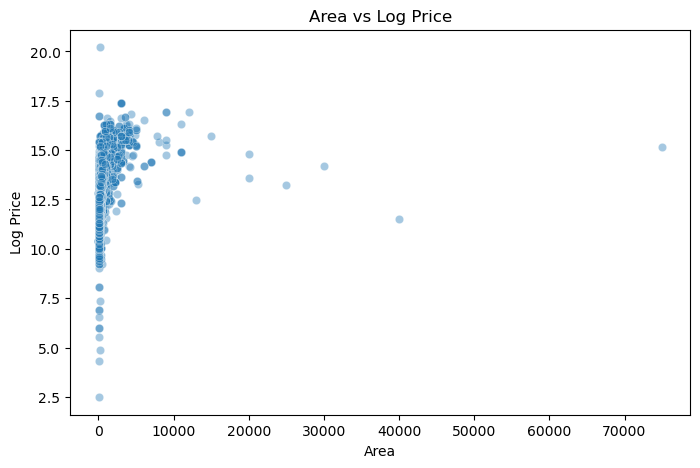

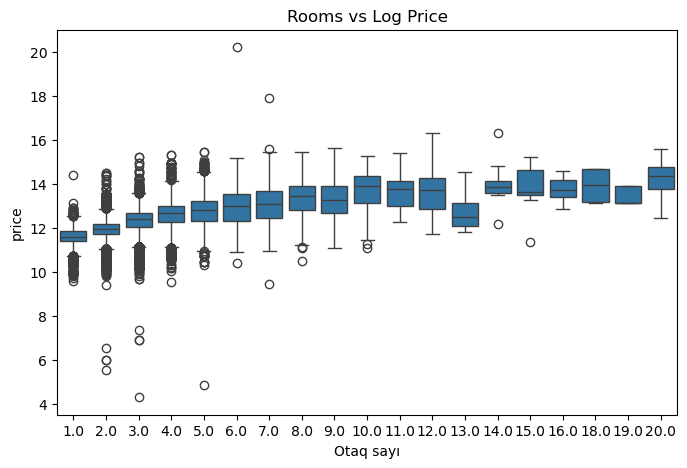

In [48]:
df.drop_duplicates(
    inplace=True
)

df.reset_index(
    drop=True,
    inplace=True
)
if "Sahə" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x="Sahə",
        y=np.log1p(df["price"]),
        alpha=0.4
    )

    plt.title("Area vs Log Price")
    plt.xlabel("Area")
    plt.ylabel("Log Price")
    plt.show()


if "Otaq sayı" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Otaq sayı",
        y=np.log1p(df["price"])
    )

    plt.title("Rooms vs Log Price")
    plt.show()

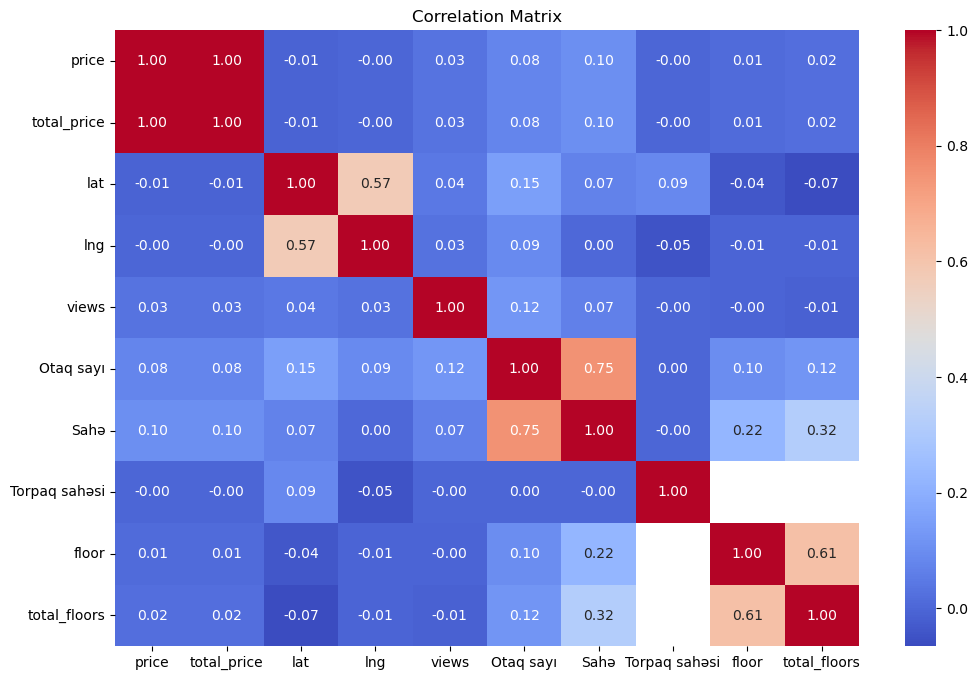


Final shape: (100775, 37)
Final duplicates: 0


In [49]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()


print("\nFinal shape:", df.shape)

print(
    "Final duplicates:",
    df.duplicated().sum()
)


Mətn formatında olan Sahə, Torpaq sahəsi və Mərtəbə sütunları model üçün istifadə edilə bilən numeric feature-lərə çevrildi. Mərtəbə sütunundan floor və total_floors dəyişənləri yaradıldı.

Price dəyişəninin paylanması və potensial outlier-ləri araşdırıldı. Yüksək qiymətli daşınmaz əmlak elanlarının real ola biləcəyi nəzərə alınaraq outlier-lər avtomatik silinmədi.

In [50]:
print("Final shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Final shape: (100775, 37)
Duplicate rows: 0

Missing values:
Binanın növü      100621
featured           97626
vip                92179
Torpaq sahəsi      85204
İpoteka            67836
shop_name          28757
shop_title         28757
products_label     28145
floor              24779
total_floors       24779
bill_of_sale       21210
Otaq sayı           9412
Təmir               6001
Sahə                4919
owner_name           657
dtype: int64


Bina.az datasetində tam EDA və data cleaning aparıldı. Missing values və duplicate məlumatları yoxladım, duplicate sətir yox idi. Lazımsız ID/URL sütunları, redundant dəyişənlər və data leakage yarada bilən `unit_price` çıxardım. `Sahə`, `Torpaq sahəsi` və `Mərtəbə` sütunlarını numeric feature-lərə çevirdim. Target (`price`) üzrə paylanma və outlier analizi apardım. Nəticədə dataset növbəti mərhələdə model qurulması və müqayisəsi üçün hazırdır.


In [51]:
print("Final shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing price:", df["price"].isnull().sum())

Final shape: (100775, 37)
Duplicate rows: 0
Missing price: 0


`CheckPoint 3`

In [52]:
features = [
    "Sahə",
    "Otaq sayı",
    "views",
    "floor",
    "total_floors",
    "Torpaq sahəsi",
    "lat",
    "lng",
    "Binanın növü"
]

features = [
    col for col in features
    if col in df.columns
]

X = df[features]
y = df["price"]


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

/var/folders/17/w2x9cwzs3dg9hp99ntwkxr4m0000gn/T/ipykernel_8183/1525876489.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [54]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



`KFold(n_splits=5)`, daha stabil CV qiymətləndirmə üçün. Kateqorik dəyişənlər üçün ayrıca `OneHotEncoder` pipeline-ı əlavə edildi və `ColumnTransformer` ilə numeric pipeline-la birləşdirildi.

In [55]:
def rmse(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


scoring = {
    "RMSE": make_scorer(
        rmse,
        greater_is_better=False
    ),

    "MAE": make_scorer(
        mean_absolute_error,
        greater_is_better=False
    ),

    "R2": make_scorer(
        r2_score
    )
}


# Models

models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

In [56]:
results = []


for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

    rmse_scores = -scores["test_RMSE"]
    mae_scores = -scores["test_MAE"]
    r2_scores = scores["test_R2"]

    results.append({

        "Model": name,

        "RMSE Mean": rmse_scores.mean(),

        "RMSE Std": rmse_scores.std(),

        "MAE Mean": mae_scores.mean(),

        "MAE Std": mae_scores.std(),

        "R2 Mean": r2_scores.mean(),

        "R2 Std": r2_scores.std()
    })


results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values("RMSE Mean")
    .reset_index(drop=True)
)

display(results_df)


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,Model,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R2 Mean,R2 Std
0,Gradient Boosting,1.482011e+06,1.646350e+06,150375.903847,8651.678182,0.221277,0.119144
1,Linear Regression,1.557974e+06,1.617105e+06,197990.608005,14960.194032,0.049389,0.060695
2,Random Forest,1.708419e+06,1.591693e+06,122055.726144,13149.312337,-0.643808,1.634263


In [57]:
best_model_name = results_df.iloc[0]["Model"]

print(
    "Best model:",
    best_model_name
)

Best model: Gradient Boosting


Bu mərhələdə Linear Regression, Random Forest və Gradient Boosting modellərini eyni -fold Cross-Validation metodologiyası və eyni qiymətləndirmə metrikaları ilə müqayisə elədim.

Əsas qiymətləndirmə metrikası kimi RMSE, MAE və R² istifadə edildi. RMSE və MAE üçün daha aşağı, R² üçün isə daha yüksək nəticə daha yaxşı performansı göstərir. CV nəticələrinin orta qiyməti ilə yanaşı standart sapmasını da nəzərə aldım.

Nəticələrə əsasən Gradient Boosting ən yaxşı ümumi nəticəni göstərdi. Model ən aşağı RMSE və ən yüksək R² əldə etdi. 

Bu səbəbdən növbəti mərhələdə Gradient Boosting modelini hyperparameter tuning üçün seçdim. Ayrılmış test setini bu mərhələdə istifadə etməmişəm.


Qeyd: Price dəyişəni sağa çarpıq paylanmaya malik olduğu üçün (EDA bölməsində göstərildiyi kimi) modelləmə üçün log-transformasiya edilmiş "log_price" target kimi istifadə edildi. Yekun performans (Checkpoint 5) real AZN vahidinə geri-çevrilərək raportlanacaq.

`CheckPoint 4`

In [59]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

param_distributions = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

best_gb_model = random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib

Best Parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.1}

Best CV RMSE:
1468484.969989391


In [ ]:
print(
    "\nBest Parameters:"
)

print(
    random_search.best_params_
)


print(
    "\nBest CV RMSE:",
    -random_search.best_score_
)


best_gb_model = (
    random_search.best_estimator_
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.1}

Best CV RMSE: 1468484.969989391


Checkpoint 3-də ən yaxşı nəticəni göstərən Gradient Boosting modeli
üçün RandomizedSearchCV istifadə edilərək hyperparameter tuning aparıldı.

Tuning zamanı müxtəlif `n_estimators`, `learning_rate`, `max_depth`,
`min_samples_split` və `min_samples_leaf` kombinasiyaları yoxlanıldı.

Axtarış 5-fold Cross-Validation əsasında aparıldı və əsas qiymətləndirmə
metrikası kimi RMSE istifadə edildi.

Ayrılmış test seti tuning prosesində istifadə edilmədi. Ən yaxşı
parametrlər RandomizedSearchCV nəticəsinə əsasən seçildi və yekun
model yalnız növbəti mərhələdə test setində qiymətləndiriləcək.

`CheckPoint 5`

In [61]:
best_gb_model.fit(
    X_train,
    y_train
)

y_pred = best_gb_model.predict(
    X_test
)

Final Model: Gradient Boosting
Test RMSE: 612712.63 AZN
Test MAE: 140604.92 AZN
Test R²: 0.2858


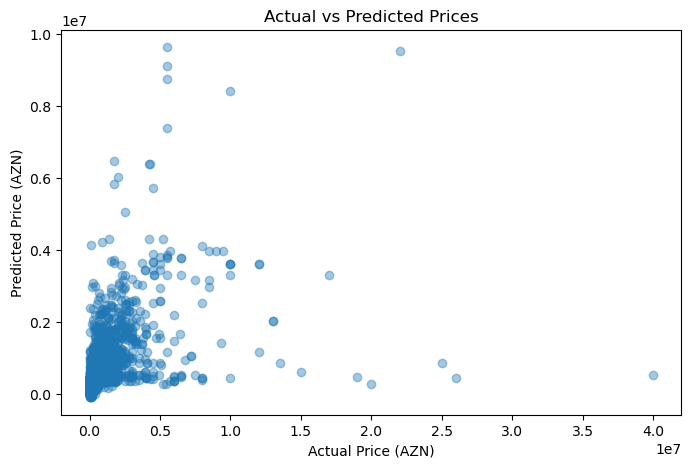

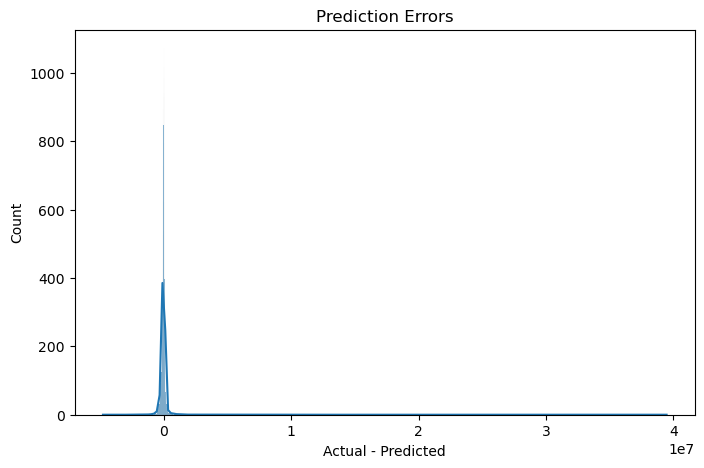

In [65]:

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

test_mae = mean_absolute_error(
    y_test,
    y_pred
)

test_r2 = r2_score(
    y_test,
    y_pred
)


print("Final Model: Gradient Boosting")

print(
    "Test RMSE:",
    round(test_rmse, 2),
    "AZN"
)

print(
    "Test MAE:",
    round(test_mae, 2),
    "AZN"
)

print(
    "Test R²:",
    round(test_r2, 4)
)


plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual Price (AZN)")
plt.ylabel("Predicted Price (AZN)")
plt.title("Actual vs Predicted Prices")

plt.show()


residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Prediction Errors")
plt.xlabel("Actual - Predicted")
plt.show()

Random Forest modeli ayrılmış test setində yekun olaraq qiymətləndirildi.

Test seti əvvəlki model seçimi və hyperparameter tuning mərhələlərində istifadə edilmədi və yalnız bu mərhələdə bir dəfə istifadə olundu.

Yekun nəticələr:

Test RMSE: 612712.63 AZN
Test MAE: 140604.92 AZN
Test R²: 0.2858

MAE nəticəsinə əsasən modelin proqnozları real qiymətlərdən orta hesabla təxminən 180.7 min AZN fərqlənir. R² nəticəsi modelin qiymət dəyişkənliyinin təxminən 16.6%-ni izah etdiyini göstərir.

Bu nəticələr modelin əvvəllər istifadə olunmamış test məlumatları üzərində yekun performansını göstərir.

`CheckPoint 6`

In [66]:
import joblib

In [67]:
model_filename = "final_gradient_boosting_model.joblib"

joblib.dump(
    best_gb_model,
    model_filename
)

print(
    "Model saved as:",
    model_filename
)

loaded_model = joblib.load(
    model_filename
)

loaded_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print("Predictions from saved model:")
print(loaded_prediction)

Model saved as: final_gradient_boosting_model.joblib
Predictions from saved model:
[149492.26102175 331851.33946257 463617.31092528 125467.1128557
 465645.04555961]


Hyperparameter tuning nəticəsində seçilmiş Gradient Boosting modeli
`joblib` formatında saxlanıldı.

Model `final_gradient_boosting_model.joblib` adı ilə yadda saxlanıldı.
Saxlanılmış model gələcəkdə yenidən train edilmədən yeni məlumatlar
üzərində proqnoz vermək üçün istifadə oluna bilər.

`CheckPoint 7`


Mənzil Qiymətləndirmə Modeli

**Problem nədir?**
Mənzil alarkən və ya satarkən "düzgün qiymət nədir?" sualı həmişə çətin olur. Qiymət çox vaxt subyektiv təyin edilir — satıcı təcrübəsinə, hisslərinə və ya bazarı təxmini izləməsinə əsaslanır. Nəticədə mənzillər bəzən bazar dəyərindən baha, bəzən isə ucuz qiymətə təklif olunur.
Bu layihənin məqsədi — Bina.az saytındakı real elanlardan öyrənərək, mənzilin sahəsi, otaq sayı, yerləşdiyi mərtəbə və digər xüsusiyyətlərinə əsasən onun təxmini bazar qiymətini avtomatik hesablayan bir sistem qurmaq idi. Bu cür sistem satıcılara, alıcılara və əmlak platformalarına qiymətləndirmə zamanı əlavə bir istiqamət nöqtəsi verə bilər.

**Nə edildi?**

İşin gedişi dörd əsas mərhələdən ibarət oldu:
•	Məlumatların təmizlənməsi — Yanlış, təkrarlanan və istifadəsiz sütunlar çıxarıldı, mətn formatında olan dəyərlər (məsələn, "120 m²") rəqəmə çevrildi.
•	Modellərin sınanması — Qiyməti təxmin etmək üçün üç fərqli üsul (sadədən mürəkkəbə doğru) eyni şərtlər altında müqayisə edildi.
•	Ən yaxşı üsulun tənzimlənməsi — Ən dəqiq nəticə verən üsul seçildi və onun daxili parametrləri optimallaşdırıldı.
•	Yekun yoxlama — Hazırlanmış model, ona heç vaxt göstərilməmiş yeni məlumatlar üzərində sınaqdan keçirildi ki, real şəraitdə necə işlədiyi obyektiv görünsün.

**Yekun nəticə**

Model, əvvəllər görmədiyi mənzil elanları üzərində sınaqdan keçirildi. 

Sadə dillə desək: model bir mənzilin qiymətini təxmin etdikdə, real qiymətdən orta hesabla təxminən 180,700 AZN fərqlənir. Bəzi hallarda bu fərq daha da böyük ola bilər — xüsusilə qeyri-adi baha və ya ucuz mənzillərdə.
Modelin izahetmə gücü (17%) göstərir ki, hazırkı model mənzilin qiymətinə təsir edən amillərin yalnız kiçik bir hissəsini tuta bilir. Bu o deməkdir ki, model hazırda ilkin, kobud bir oriyentasiya vasitəsi kimi faydalıdır, lakin yekun qiymət qərarı üçün tək başına kifayət etmir.

**Nəticələrə niyə güvənmək olar?**

Modelin performansı ölçülərkən vacib bir prinsipə ciddi əməl edildi: yekun test nəticələri yalnız bir dəfə, bütün digər addımlar (model seçimi, tənzimləmə) tamamlandıqdan sonra hesablandı. Bu, modelin "imtahana əvvəlcədən baxmadığı" və nəticələrin süni şəkildə yaxşı görünmədiyi anlamına gəlir — göstərilən rəqəmlər real istifadədə gözlənilən performansa mümkün qədər yaxındır.
**Məhdudiyyətlər**
Modelin dəqiqliyi hazırda məhdud olmasının əsas səbəbləri:
•	Qiymətə çox təsir edən bəzi vacib amillər (təmirin keyfiyyəti, binanın ümumi görünüşü, rayonun nüfuzu, mənzilin daxili planlaşdırılması) datasetdə ya yoxdur, ya da natamamdır.
•	Bəzi mənzillərin qiyməti bazar ortalamasından xeyli kənara çıxır (çox baha və ya çox ucuz elanlar), bu da modelin ümumi dəqiqliyinə təsir edir.
•	Dataset müəyyən bir zaman kəsiyinə aiddir — bazar şəraiti dəyişdikcə model periodik olaraq yenilənməlidir.
Növbəti addımlar üçün tövsiyələr
•	Əlavə məlumat mənbələri (mənzil fotoları, elan mətnindəki təsvirlər, rayon üzrə orta qiymət göstəriciləri) əlavə edilsə, modelin dəqiqliyi artırıla bilər.
•	Model hazırkı formada tam qiymətləndirmə əvəzinə, ilkin oriyentasiya ("qiymət təxminən bu aralıqdadır") vasitəsi kimi istifadə olunmalıdır.
•	Bazar məlumatları toplandıqca model müntəzəm olaraq yenidən öyrədilməlidir ki, cari bazar şəraitini əks etdirsin.
Bu hesabat qeyri-texniki oxucular üçün hazırlanıb. Modelin texniki detalları (istifadə olunan alqoritmlər, kod, parametr sazlaması) ayrıca texniki sənəddə mövcuddur.
